### Importación de Bibliotecas

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from keras.models import Sequential
from keras.datasets import boston_housing
from keras import layers, models, optimizers
import matplotlib.pyplot as plt

## Carga de Datos

In [2]:
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [3]:
train_data.shape[1]

13

In [4]:
train_targets.shape

(404,)

## Estandarización de Datos

In [5]:
standard_scaler = StandardScaler()

train_data = standard_scaler.fit_transform(train_data)
test_data = standard_scaler.transform(test_data)

## Función de Entrenamiento 

In [22]:
def build_model(input_data, learning_rate):
    model=models.Sequential()
    model.add(layers.Dense(50, activation='relu', input_shape=(input_data.shape[1],)))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(50, activation='relu'))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(1))
    model.compile(optimizer=optimizers.RMSprop(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

## Validación cruzada K-Fold

Entrenando Fold 1...
Entrenando Fold 2...
Entrenando Fold 3...
Entrenando Fold 4...


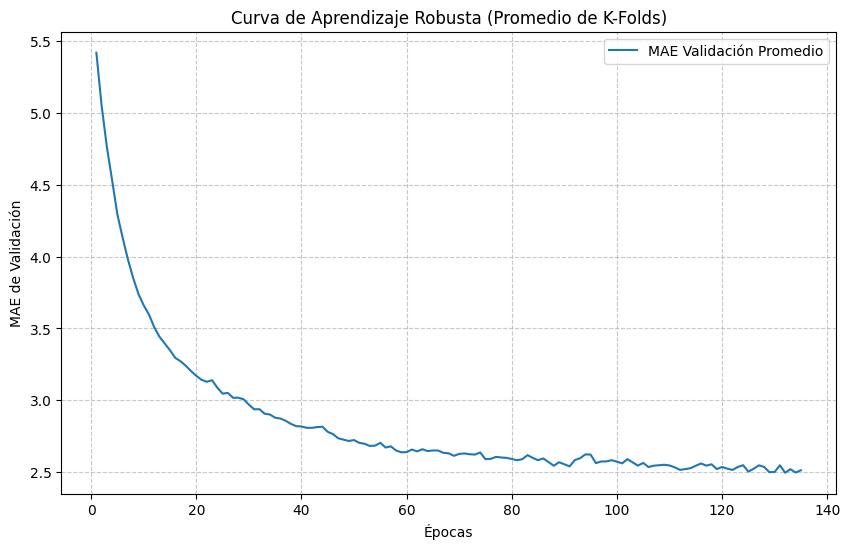

In [23]:
k = 4
num_epochs = 150
kfold = KFold(n_splits=k, shuffle=True, random_state=42)
all_mae_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(train_data)):
    print(f"Entrenando Fold {fold_idx + 1}...")
    # 1. Crear el modelo (importante: debe ser un modelo nuevo en cada iteración)
    model = build_model(learning_rate=0.0005, input_data=train_data)
    
    # 2. Entrenar
    history=model.fit(train_data[train_idx], train_targets[train_idx], validation_data=(train_data[val_idx], train_targets[val_idx]),
              epochs=num_epochs, batch_size=16, verbose=0)
    
    # Extraemos el MAE de validación de este entrenamiento
    mae_history = history.history['val_mae']
    all_mae_histories.append(mae_history)
    
    
# 4. Promediando las curvas de los K-Folds
# Calculamos la media de MAE para cada época entre los 4 folds
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

# 5. Gráfica de Validación Robusta
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(average_mae_history[15:]) + 1), average_mae_history[15:], label='MAE Validación Promedio')
plt.title('Curva de Aprendizaje Robusta (Promedio de K-Folds)')
plt.xlabel('Épocas')
plt.ylabel('MAE de Validación')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Entrenamiento final y evaluación en el conjunto de prueba

In [24]:
# Entrenamos el modelo final con TODO el dataset de entrenamiento
model_final = build_model(input_data=train_data, learning_rate=0.0005)

model_final.fit(train_data, train_targets,
                epochs=125, # Usamos el número óptimo según tu gráfica
                batch_size=16, 
                verbose=0)

In [25]:
test_mse_score, test_mae_score = model_final.evaluate(test_data, test_targets)

print(f"MAE Final en datos de prueba: {test_mae_score:.3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 20.2391 - mae: 2.9924 
MAE Final en datos de prueba: 2.992


In [26]:
# Realizamos las predicciones
predictions = model_final.predict(test_data)

# Mostramos las primeras 5 comparaciones
for i in range(5):
    print(f"Real: ${test_targets[i]:.1f}k | Predicho: ${predictions[i][0]:.1f}k")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Real: $7.2k | Predicho: $8.1k
Real: $18.8k | Predicho: $17.0k
Real: $19.0k | Predicho: $20.3k
Real: $27.0k | Predicho: $32.7k
Real: $22.2k | Predicho: $24.4k
